In [8]:
import pandas as pd
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline 
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from catboost import CatBoostRegressor




In [10]:
df=pd.read_csv('data.csv')

In [11]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [56]:
x=df.select_dtypes(include=object)
y=df['total score']
y.head()
x.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course
0,female,group B,bachelor's degree,standard,none
1,female,group C,some college,standard,completed
2,female,group B,master's degree,standard,none
3,male,group A,associate's degree,free/reduced,none
4,male,group C,some college,standard,none


In [57]:
x['maths score']=df['math_score']

In [58]:
x.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,maths score
0,female,group B,bachelor's degree,standard,none,72
1,female,group C,some college,standard,completed,69
2,female,group B,master's degree,standard,none,90
3,male,group A,associate's degree,free/reduced,none,47
4,male,group C,some college,standard,none,76


In [59]:
categorical_features=x.select_dtypes(include=object).columns

In [60]:
numerical_features=x.select_dtypes(exclude=object).columns

In [61]:
numerical_features

Index(['maths score'], dtype='object')

In [62]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

In [63]:
#pas only columns names to column transformers
standard_scaler=StandardScaler()
onehotencoder=OneHotEncoder()
preprocessor=ColumnTransformer([
    ("OneHotEncoder",onehotencoder,categorical_features),
                                ("StandardScaler",standard_scaler,numerical_features)
                                ])

In [64]:
x=preprocessor.fit_transform(x)

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [72]:
def evaluate(y,pred):
    mae=mean_absolute_error(y,pred)
    mse=mean_squared_error(y,pred)
    r2=r2_score(y,pred)
    rmse=np.sqrt(mean_squared_error(y,pred))
    print("\nmean_absolute_error:",mae)
    print("\nmean_squared_error:",mse)
    print("\nr2_score:",r2)
    print("\nrmse:",rmse)
    return r2


In [68]:
model={
    'linear regression':LinearRegression(),
    'support vecotr':SVR(),
    'Ridge':Ridge(),
    'Lasso':Lasso(),
    'knn':KNeighborsRegressor(),
    'decision tree':DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'xgboost':XGBRegressor(),
    'catboosting':CatBoostRegressor(),
    'adaboost':AdaBoostRegressor()

}


In [75]:
mod=[]
r2=[]

In [76]:
for i in range(len(list(model))):
    models=list(model.values())[i]
    models.fit(xtrain,ytrain)
    predtrain=models.predict(xtrain)
    pred=models.predict(xtest)
    print(list(model.keys())[i])
    print("\nfor train data:")
    evaluate(ytrain,predtrain)
    print("\nfor test data")
    r=evaluate(ytest,pred)
    r2.append(r)
    mod.append(list(model.keys())[i])
    

linear regression

for train data:

mean_absolute_error: 8.241062728713878

mean_squared_error: 106.33944298689123

r2_score: 0.9407594537634589

rmse: 10.312101773493668

for test data

mean_absolute_error: 8.057489639268237

mean_squared_error: 103.59604352306901

r2_score: 0.9463037931635022

rmse: 10.178214161780495
support vecotr

for train data:

mean_absolute_error: 14.929155599913006

mean_squared_error: 429.65385672718594

r2_score: 0.760644512983835

rmse: 20.728093417562214

for test data

mean_absolute_error: 16.208283695530948

mean_squared_error: 640.9553830394566

r2_score: 0.667778115358341

rmse: 25.317096655016677
Ridge

for train data:

mean_absolute_error: 8.241469337842267

mean_squared_error: 106.34595688457802

r2_score: 0.9407558249419581

rmse: 10.312417606195844

for test data

mean_absolute_error: 8.062248290460424

mean_squared_error: 103.66700921052154

r2_score: 0.9462670100190678

rmse: 10.181699721093798
Lasso

for train data:

mean_absolute_error: 9.193

In [78]:
r

0.91147858942601

In [79]:
result=pd.DataFrame(zip(mod,r2),columns=['model','r2_score'])

In [80]:
result

,model,r2_score
0,linear regression,0.946304
1,support vecotr,0.667778
2,Ridge,0.946267
3,Lasso,0.934581
4,knn,0.815979
5,decision tree,0.894646
6,random forest,0.920850
7,xgboost,0.916848
8,catboosting,0.928084
9,adaboost,0.911479


LINEAR REGRESSION

In [81]:
lin=LinearRegression(fit_intercept=True)
lin.fit(xtrain,ytrain)
pred=lin.predict(xtest)
score=r2_score(ytest,pred)*100
print("score:",score)



score: 94.63037931635021


plot bestfit line 

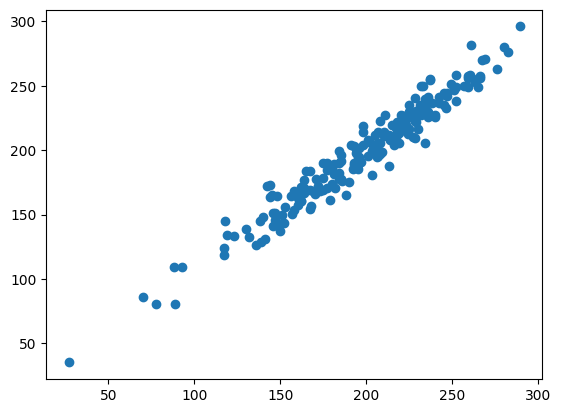

In [ ]:
plt.scatter(ytest,pred)
plt.

<Axes: xlabel='total score'>

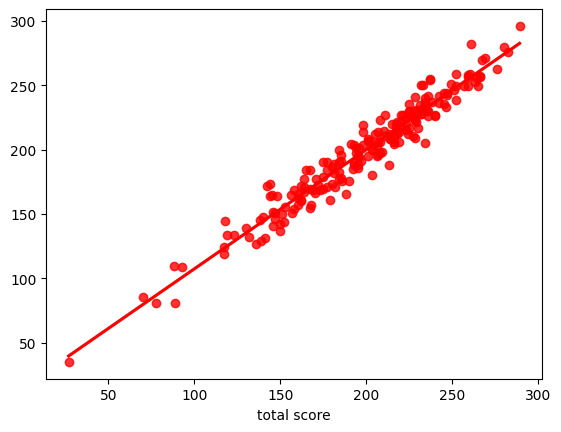

In [83]:
sns.regplot(x=ytest,y=pred,ci=None,color='red')

In [84]:
pred=pd.DataFrame({'actual value':ytest,'predicted values':pred,'difference':ytest-pred})

In [86]:
pred.head()

,actual value,predicted values,difference
521,261,281.608110,-20.608110
737,192,185.110018,6.889982
740,225,229.326073,-4.326073
660,224,212.252234,11.747766
411,245,235.300489,9.699511
